In [1]:
#imports

import pandas as pd 
import numpy as np 
import datetime
import matplotlib.pyplot as plt

In [2]:
# Loading Datasets

stock = pd.read_csv("HistoricalData_GOOGLE.csv")
treasury = pd.read_csv("HistoricalData_10YrTreasury.csv")

In [3]:
#Standardizing Alphabet(Google) Stock Price Dataset

stock["Date"] = pd.to_datetime(stock["Date"])
stock["Close/Last"] = stock["Close/Last"].replace(r"[\$,]", "", regex=True).astype(float)
stock = stock.drop(columns = ["Volume", "Open", "High", "Low"])
stock = stock.rename(columns = {"Close/Last": "Price"})
print(stock)

           Date     Price
0    2026-03-11  308.4200
1    2026-03-10  306.9300
2    2026-03-09  306.0100
3    2026-03-06  298.3000
4    2026-03-05  300.9100
...         ...       ...
1250 2021-03-18  101.8110
1251 2021-03-17  104.5540
1252 2021-03-16  104.6260
1253 2021-03-15  103.3245
1254 2021-03-12  103.0960

[1255 rows x 2 columns]


In [4]:
# Identifying variable formats

stock.dtypes

Date     datetime64[ns]
Price           float64
dtype: object

In [5]:
#Checking for missing values

stock.isnull().sum()

Date     0
Price    0
dtype: int64

In [6]:
# Identifying variable formats

treasury.dtypes

observation_date     object
DGS10               float64
dtype: object

In [7]:
#Checking for missing values

treasury.isnull().sum()

observation_date     0
DGS10               55
dtype: int64

In [8]:
#Standardizing US 10-year Treasury Yield Dataset

treasury = treasury.rename(columns = {"observation_date": "Date", "DGS10": "Treasury Rate"})
treasury["Date"] = pd.to_datetime(treasury["Date"])

In [9]:
# Merging both datasets

merged_dataset = pd.merge(stock, treasury, on="Date", how="inner")

In [10]:
#Filling missing values

merged_dataset["Treasury Rate"] = merged_dataset["Treasury Rate"].ffill()
merged_dataset["Return"] = merged_dataset["Price"].pct_change()
print(merged_dataset)

           Date     Price  Treasury Rate    Return
0    2026-03-11  308.4200           4.21       NaN
1    2026-03-10  306.9300           4.15 -0.004831
2    2026-03-09  306.0100           4.12 -0.002997
3    2026-03-06  298.3000           4.15 -0.025195
4    2026-03-05  300.9100           4.13  0.008750
...         ...       ...            ...       ...
1250 2021-03-18  101.8110           1.71 -0.003416
1251 2021-03-17  104.5540           1.63  0.026942
1252 2021-03-16  104.6260           1.62  0.000689
1253 2021-03-15  103.3245           1.62 -0.012440
1254 2021-03-12  103.0960           1.64 -0.002211

[1255 rows x 4 columns]


In [11]:
#Checking for missing values

merged_dataset.isnull().sum()

Date             0
Price            0
Treasury Rate    0
Return           1
dtype: int64

In [12]:
#Calculating Daily Price Change (Value in Percent)

merged_dataset["Return"] = merged_dataset["Price"].pct_change() *100
merged_dataset["Return"]

0            NaN
1      -0.483107
2      -0.299743
3      -2.519526
4       0.874958
          ...   
1250   -0.341621
1251    2.694208
1252    0.068864
1253   -1.243955
1254   -0.221148
Name: Return, Length: 1255, dtype: float64

In [13]:
#  Benchmark Analysis

avg_daily_return = merged_dataset["Return"].mean()
annual_return = avg_daily_return * 252

daily_volatility = merged_dataset["Return"].std()
annual_volatility = daily_volatility * np.sqrt(252)

print("Average Daily Return:", avg_daily_return)
print("Annualized Return:", annual_return)
print("Daily Volatility:", daily_volatility)
print("Annualized Volatility:", annual_volatility)

Average Daily Return: -0.06887101248234782
Annualized Return: -17.35549514555165
Daily Volatility: 1.9244043616567654
Annualized Volatility: 30.548972177230823


In [14]:
# Risk to Reward Ratio

risk_to_reward = annual_volatility / annual_return

print("Risk to Reward Ratio:", risk_to_reward)

Risk to Reward Ratio: -1.7601901830533924


In [15]:
# Risk Premium

risk_premium = annual_return - ((merged_dataset["Treasury Rate"] / 100).mean())

print("Risk Premium:", risk_premium)

Risk Premium: -17.390304308898262


In [16]:
# Correlation

correlation = merged_dataset["Return"].corr(
    merged_dataset["Treasury Rate"].diff()
)

print("Correlation between Alphabet Returns and Treasury Yield Changes:")
print(correlation)

Correlation between Alphabet Returns and Treasury Yield Changes:
-0.037113628175816066


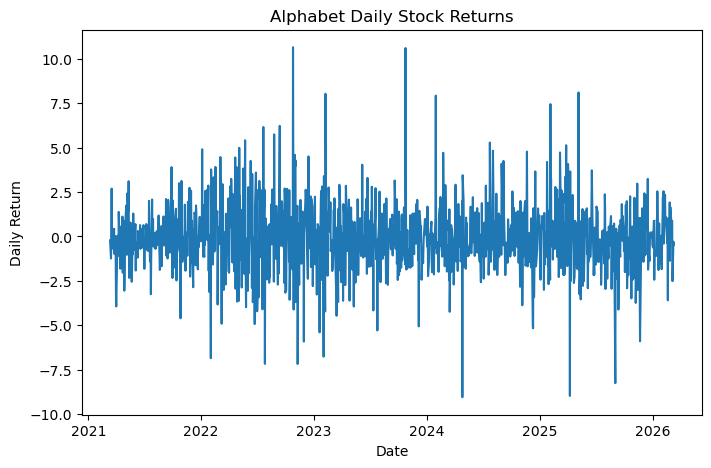

In [17]:
# DAILY STOCK RETURNS OF ALPHABET

plt.figure(figsize=(8,5))

plt.plot(
    merged_dataset["Date"],
    merged_dataset["Return"]
)

plt.title("Alphabet Daily Stock Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

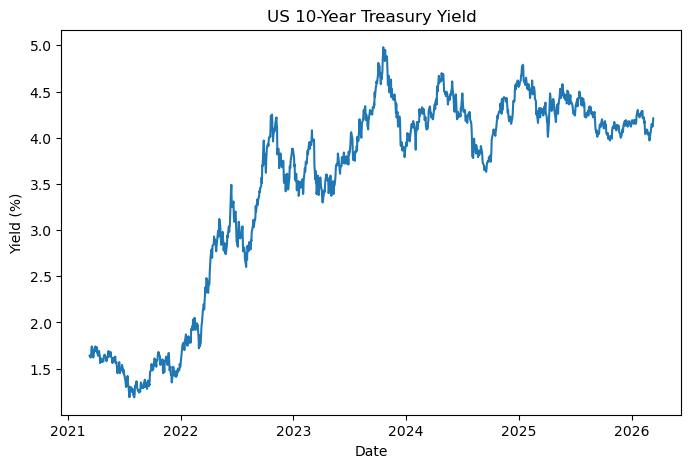

In [18]:
# TREASURY YIELD OVER TIME

plt.figure(figsize=(8,5))

plt.plot(
    merged_dataset["Date"],
    merged_dataset["Treasury Rate"]
)

plt.title("US 10-Year Treasury Yield")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.show()

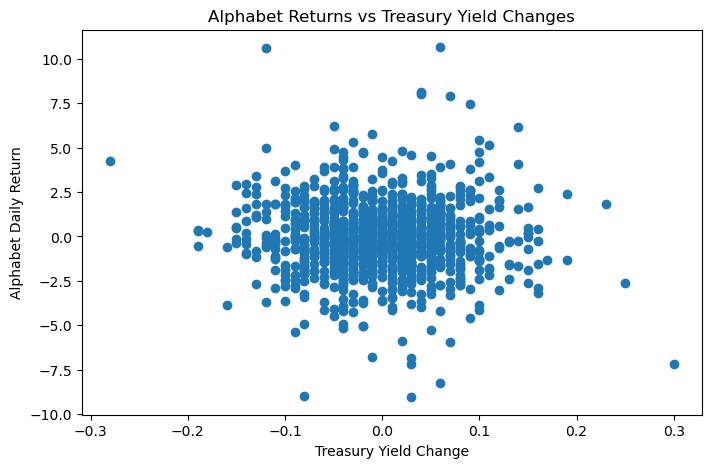

In [19]:
# RETURNS vs RATE CHANGES

plt.figure(figsize=(8,5))

plt.scatter(
    merged_dataset["Treasury Rate"].diff(),
    merged_dataset["Return"]
)

plt.title("Alphabet Returns vs Treasury Yield Changes")
plt.xlabel("Treasury Yield Change")
plt.ylabel("Alphabet Daily Return")
plt.show()

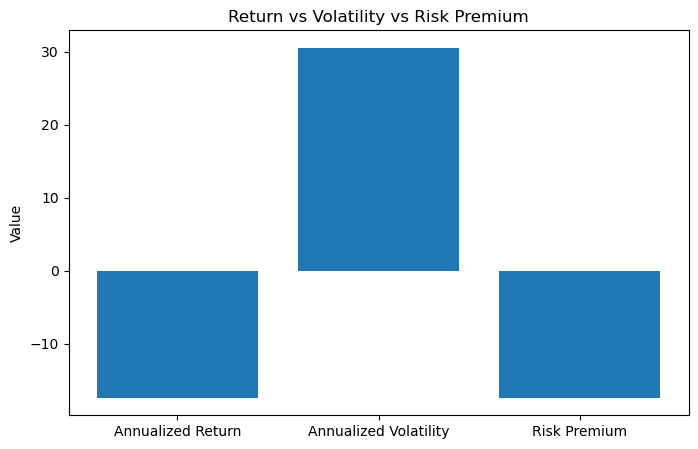

In [20]:
# RETURN vs RISK vs PREMIUM

metrics = [
    annual_return,
    annual_volatility,
    risk_premium
]

labels = [
    "Annualized Return",
    "Annualized Volatility",
    "Risk Premium"
]

plt.figure(figsize=(8,5))
plt.bar(labels, metrics)
plt.title("Return vs Volatility vs Risk Premium")
plt.ylabel("Value")
plt.show()